# Data Preparation Notebook

* #### This notebook prepares the LES turbulent airfoil [1] dataset for NO+DM training

* #### First, download the dataset from University of Michigan's Deep Blue Data Repository. 
    * Go to link (https://deepblue.lib.umich.edu/data/collections/kk91fk98z?locale=en).
    * Check section: Turbulent airfoil wake large eddy simulation
    * Download airfoilLES_snapshots_midspan.zip



* #### If this link is not working, refer [1] 

* #### [1] - Towne, Aaron, et al. "A database for reduced-complexity modeling of fluid flows." AIAA journal 61.7 (2023): 2867-2892.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib
matplotlib.rcParams["figure.dpi"] = 200
plt.rcParams["font.family"] = "serif"
import scipy.stats as stats

from scipy.interpolate import griddata
from matplotlib.path import Path

import time 
from scipy.ndimage import distance_transform_edt, generic_filter

In [3]:
# import zipfile
# import os

In [5]:
# zip_path = 'airfoilLES_snapshots_midspan.zip'

# # Specify the directory to extract to
# extract_to_path = 'temp/'

# # Create the directory if it doesn't exist
# os.makedirs(extract_to_path, exist_ok=True)

# # Open the zip file
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     # Extract all the contents into the directory
#     zip_ref.extractall(extract_to_path)

# print("Extraction Complete!")


Extraction Complete!


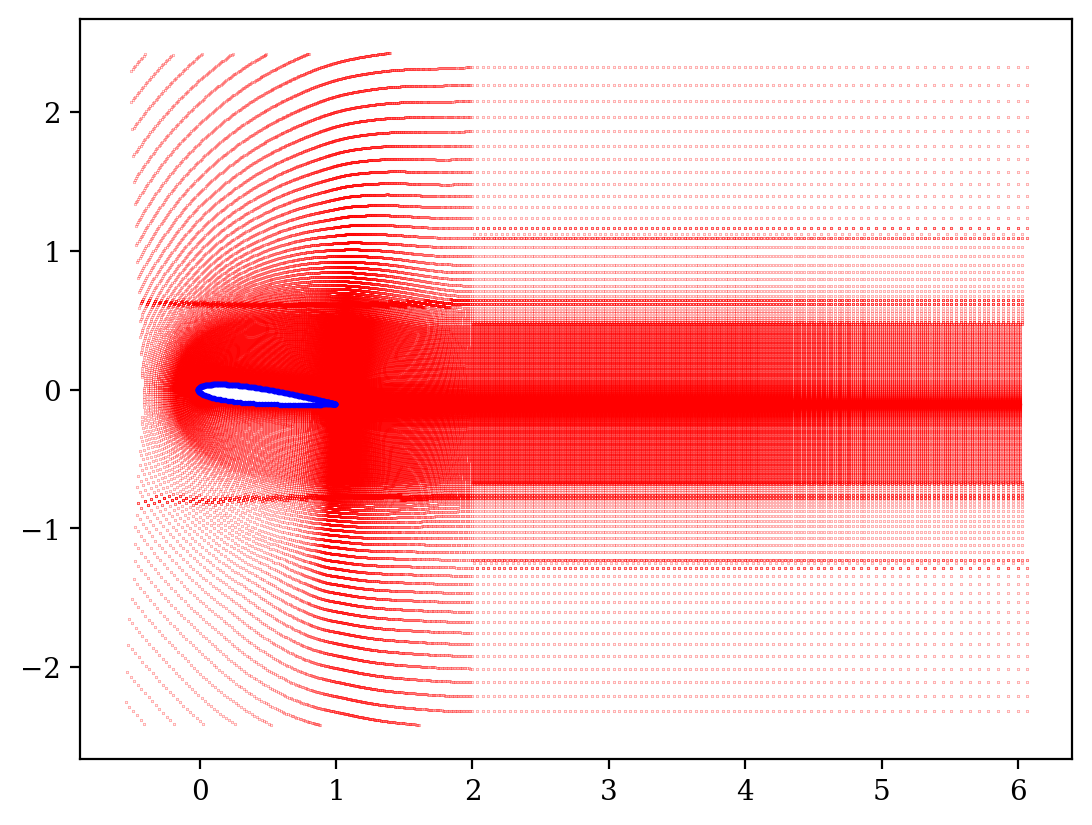

In [2]:
file = h5py.File('airfoilLES_grid.h5', 'r')
grid_x = np.array(file['x'])
grid_y = np.array(file['y'])

grid_xa = np.array(file['xa'])
grid_ya = np.array(file['ya'])

plt.scatter(grid_x, grid_y, s=.01, c='red')
plt.scatter(grid_xa, grid_ya, s=1, c='blue')
plt.show()

In [3]:
grid_x.min(), grid_x.max()

(-0.542529067, 6.066522)

In [4]:
grid_y.min(), grid_y.max()

(-2.41714124, 2.42695594)

In [3]:
def interpolate_to_grid_with_mask(grid_x, grid_y, field, NX, NY, grid_xa=None, grid_ya=None, get_mask=False):
    """
    Interpolate unstructured data (grid_x, grid_y, field) onto a structured grid of size (NX, NY)
    and create a binary mask that is 0 inside the airfoil and 1 outside.
    
    Parameters:
        grid_x (np.array): x-coordinates of the unstructured data points, shape (n_nodes,)
        grid_y (np.array): y-coordinates of the unstructured data points, shape (n_nodes,)
        field (np.array): field values at the unstructured data points, shape (n_nodes,)
        NX (int): Number of points in the structured grid along the x-axis
        NY (int): Number of points in the structured grid along the y-axis
        grid_xa (np.array): x-coordinates of the airfoil geometry, shape (n_nodesa,)
        grid_ya (np.array): y-coordinates of the airfoil geometry, shape (n_nodesa,)
    
    Returns:
        np.array: Interpolated field values on the structured grid, shape (NX, NY)
        np.array: Binary mask, 0 inside the airfoil and 1 outside, shape (NX, NY)
    """
    # Create target grid to interpolate to
    target_x = np.linspace(np.min(grid_x), np.max(grid_x), NX)
    target_y = np.linspace(np.min(grid_y), np.max(grid_y), NY)
    grid_X, grid_Y = np.meshgrid(target_x, target_y)
    
    grid_Z = griddata((grid_x, grid_y), field, (grid_X, grid_Y), method='linear')

    if get_mask:
        # Create the airfoil path
        airfoil_path = Path(np.column_stack((grid_xa, grid_ya)))
        
        # Flatten grid_X and grid_Y to use with the airfoil path
        points = np.vstack((grid_X.ravel(), grid_Y.ravel())).T
        
        # Use the airfoil path to create the mask
        inside_airfoil = airfoil_path.contains_points(points).reshape(NX, NY)
        mask = np.where(inside_airfoil, 0, 1)  # 0 inside the airfoil, 1 outside

    else:
        mask=None
    
    return grid_Z, mask

In [4]:
NX = 1024
NY = 1024

delta_y = 128
skip_x = skip_y = 2

file = h5py.File('airfoilLES_grid.h5', 'r')
grid_x = np.array(file['x'])
grid_y = np.array(file['y'])

grid_xa = np.array(file['xa'])
grid_ya = np.array(file['ya'])

ux_ls = []
# uy_ls = []
# uz_ls = []
for i in tqdm(range(1,5001,5)):
    t_idx = str(100000+i)[1:]
    file = h5py.File(f'temp/airfoilLES_midspan/airfoilLES_t{t_idx}.h5', 'r')
    # print(list(file))
    
    ux = np.array(file["ux"])

    field = ux
    if i==1:
        grid_field, grid_mask = interpolate_to_grid_with_mask(grid_x, grid_y, field, NX, NY, grid_xa, grid_ya, get_mask=True)
        grid_mask = grid_mask[512-delta_y:512+delta_y][::skip_x, ::skip_y]
    else:
        grid_field, _ = interpolate_to_grid_with_mask(grid_x, grid_y, field, NX, NY)


    temp_grid_field = grid_field[512-delta_y:512+delta_y][::skip_x, ::skip_y]
    
    ux_ls.append(temp_grid_field)
    
    # uy = np.array(file["uy"])
    # uy_ls.append(uy)

    # uz = np.array(file["uz"])
    # uz_ls.append(uz)
    
    file.close()

UX = np.array(ux_ls)
# np.save("UX.npy", UX)

100%|██████████| 1000/1000 [1:02:01<00:00,  3.72s/it]


In [5]:
UX.shape

(1000, 128, 512)

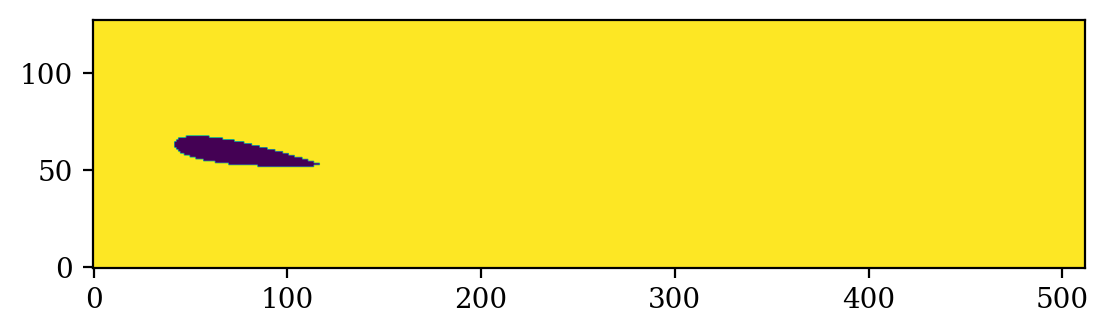

In [6]:
plt.imshow(grid_mask, origin='lower')

In [7]:
np.save("mask.npy", grid_mask)

# Remove NANs

In [41]:
def fill_nan_with_nearest(data):
    """
    Replace NaN values in the 3D dataset with the nearest non-NaN neighbor.

    Parameters:
        data (np.array): Input 3D array with shape (nt, nx, ny) containing NaNs.

    Returns:
        np.array: Modified array with NaNs replaced by nearest non-NaN neighbors.
    """
    # Mask of NaNs
    nan_mask = np.isnan(data)
    
    # Indices where there are non-NaN values
    filled_mask = ~nan_mask
    
    # Perform an inverse distance transform where non-NaN values are zero (close) and NaNs are high (far)
    distances, indices = distance_transform_edt(nan_mask, return_indices=True)
    
    # Replace NaNs by using the indices to pull values from nearest non-NaNs
    filled_data = data[tuple(indices)]
    
    # Only update NaN positions
    data[nan_mask] = filled_data[nan_mask]
    
    return data

In [50]:
UX = np.load("UX.npy")
UX_nan_filtered = fill_nan_with_nearest(UX)

In [53]:
np.sum(np.isnan(grid_mask))

0

In [52]:
np.save("UX_nan_filtered.npy", UX_nan_filtered)